# Module Lab: Decision Trees and Model Tuning (Mining)

## Scenario

You are part of a **mining reliability analytics team** supporting maintenance planning for haul trucks operating across a mine site.

Each row in the dataset represents a truck-related observation. Your task is to build a machine learning model that predicts whether a truck is likely to experience a **failure in the next 24 hours**.

This matters because missed failures can lead to:

- unplanned downtime
- production delays
- expensive emergency maintenance
- safety and operational risk

In this lab, you will use a **decision tree classifier** and improve it through **model tuning** so the model is better at identifying likely failures.

## Key ideas

This activity focuses on several important machine learning ideas:

- **classification** means predicting a category, such as failure or no failure
- the **target variable** is the column the model is trying to predict
- **features** are the input columns used by the model
- **train/test split** separates data used for learning from data used for final checking
- **cross-validation** gives a more reliable estimate of model performance
- **hyperparameters** are settings you choose before training the model
- **model tuning** searches for better hyperparameter combinations
- **recall** is especially important when missing a real failure is costly

## Why recall matters in mining

For this lab, **recall** is the main performance metric.

Recall answers this question:

> Of all the trucks that really were going to fail, how many did the model successfully identify?

In a mining environment, missing a real failure can be more serious than raising an extra inspection alert.  
That is why we optimise for recall in this notebook.

## Learning goals

By the end of this lab, you should be able to:

1. load and inspect a mining dataset
2. identify the target column and check whether the classes are imbalanced
3. build a baseline decision tree pipeline
4. understand why preprocessing is included inside the pipeline
5. tune the model with RandomizedSearchCV and GridSearchCV
6. evaluate the final model using recall, a classification report, and a confusion matrix
7. interpret feature importance in an operational mining context


## How to use this notebook

Work through the notebook from top to bottom.

### Running code cells

- Click inside a code cell.
- Press **Shift + Enter** to run it.
- Wait for the output to appear before moving to the next section.

### Recommended workflow

1. Read the explanation above the code cell.
2. Run the code cell.
3. Review the output carefully.
4. Compare the output with the explanation and prompts.
5. Answer the short discussion questions in your own words.

### If something goes wrong

- Re-run the current cell.
- Make sure the earlier setup cells have already been run.
- Check whether the dataset loaded successfully.
- If needed, restart the notebook kernel/runtime and run the notebook again from the top.

### How to read the code

Throughout the notebook, the code includes comments that explain:

- what each line or block is doing
- why that step is necessary
- what result it is trying to achieve
- why that method is appropriate for this problem


## 1) Setup: imports and utility functions


In [1]:
# Import the main Python libraries used in this lab.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import model selection tools.
# These help us split data, validate models, and search for better model settings.
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV,
    GridSearchCV,
)

# Import preprocessing tools.
# These help us handle numeric and categorical columns properly.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Import the decision tree model.
from sklearn.tree import DecisionTreeClassifier

# Import evaluation metrics.
# We use recall because missing real failures is costly in this mining scenario.
from sklearn.metrics import recall_score, confusion_matrix, classification_report

print("Environment ready ✅")

# Set a fixed random state so results are reproducible.
# This means the split and model behaviour are more consistent between runs.
RANDOM_STATE = 42


def pretty_confusion_matrix(cm, labels=("No failure", "Failure")):
    """Plot a simple confusion matrix for easier interpretation."""
    fig = plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.xticks([0, 1], labels, rotation=15)
    plt.yticks([0, 1], labels)

    # Write the count value inside each matrix cell.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


Environment ready ✅


### Why this section matters

Before building any model, we need to load the tools required for:

- handling data
- preprocessing features
- training a model
- evaluating the model
- tuning model settings

The helper function for the confusion matrix is included so the results are easier to read visually.


## 2) Load the dataset

The dataset is stored at a public CSV URL.

### What to look for after running the next cell

Check the following:

- the dataset loads successfully
- the target column `failure_next_24h` exists
- the dataset has roughly 6,000 rows
- the target is imbalanced, with only a small proportion of positive cases

This imbalance matters because it affects how we judge model performance.


In [2]:
# Store the dataset URL in a variable so it is easy to re-use or replace later.
CSV_URL = "https://articulateusercontent.com/rise/courses/YWT7FMIRejmBZjpv9TB0tG7M0urC50z0/4fdMmQiHlibm0L1r.csv"

# Read the CSV file into a pandas DataFrame.
# A DataFrame is like a spreadsheet table inside Python.
df = pd.read_csv(CSV_URL)

# Display the first few rows so we can visually inspect the structure.
display(df.head())

# Print the overall size and the available columns.
print("\nShape:", df.shape)
print("Columns:", list(df.columns))

# Define the target column name once so we can re-use it throughout the notebook.
TARGET = "failure_next_24h"

# Check that the expected target column exists.
assert TARGET in df.columns, f"Expected target column '{TARGET}' not found"

# Calculate the proportion of positive cases.
# This shows how common future failure events are in the dataset.
pos_rate = df[TARGET].mean()
print(f"Positive rate ({TARGET}=1): {pos_rate:.3%}")


,truck_model,site,shift,hours_since_service,vibration_mm_s,engine_temp_c,load_tonnes,ambient_temp_c,engine_oil_pressure_kpa,fuel_rate_lph,speed_kmh,fault_code_count,over_temp_flag,high_vibration_flag,failure_next_24h
0,Komatsu 930E,Pit A,Day,273.1,6.46,98.300000,185.7,29.9,440.4,541.5,30.0,1,1,1,0
1,CAT 793F,Pit A,Day,148.0,3.61,89.200000,196.0,24.7,492.5,589.2,20.2,1,0,0,0
2,Liebherr T 284,Pit B,Day,474.7,3.42,83.800000,221.4,39.3,408.0,456.0,32.1,2,0,0,0
3,Komatsu 930E,Pit A,Night,463.4,4.59,67.300000,164.1,24.8,485.2,543.6,33.0,1,0,0,0
4,CAT 793F,Pit A,Day,31.9,2.83,110.834416,192.1,51.5,456.5,519.3,16.7,0,0,0,0



Shape: (6000, 15)
Columns: ['truck_model', 'site', 'shift', 'hours_since_service', 'vibration_mm_s', 'engine_temp_c', 'load_tonnes', 'ambient_temp_c', 'engine_oil_pressure_kpa', 'fuel_rate_lph', 'speed_kmh', 'fault_code_count', 'over_temp_flag', 'high_vibration_flag', 'failure_next_24h']
Positive rate (failure_next_24h=1): 5.517%


### Why we do this

This step confirms that the dataset is usable before we start modelling.

In particular, we check the target because:

- if the target is missing, the lab cannot continue
- if the positive class is rare, accuracy alone would be misleading
- knowing the class balance helps explain why recall is important


## 3) Build the baseline model

We now create a first version of the decision tree model.

### What happens in this stage

We will:

1. separate features `X` from target `y`
2. create a **train/test split**
3. identify numeric and categorical columns
4. define preprocessing for each column type
5. create a pipeline that combines preprocessing and modelling
6. evaluate the baseline model using cross-validation with **recall**

### Why use a pipeline?

A pipeline keeps preprocessing and modelling together in one workflow.

This is important because:

- it reduces manual errors
- it ensures the same transformations are used consistently
- it avoids data leakage during validation


In [4]:
# Separate the input features from the target column.
# X contains the predictors, and y contains the outcome we want to predict.
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# Split the dataset into training and test sets.
# - The training set is used for model building and tuning.
# - The test set is kept aside for final evaluation only.
# - stratify=y keeps the class balance similar in both splits.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Identify numeric columns automatically.
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Treat all remaining columns as categorical.
cat_cols = [c for c in X_train.columns if c not in num_cols]

print("Number of training rows:", X_train.shape[0])
print("Number of test rows:", X_test.shape[0])
print("\nNumeric columns:", num_cols)
print("\nCategorical columns:", cat_cols)


Number of training rows: 4800
Number of test rows: 1200

Numeric columns: ['hours_since_service', 'vibration_mm_s', 'engine_temp_c', 'load_tonnes', 'ambient_temp_c', 'engine_oil_pressure_kpa', 'fuel_rate_lph', 'speed_kmh', 'fault_code_count', 'over_temp_flag', 'high_vibration_flag']

Categorical columns: ['truck_model', 'site', 'shift']


In [5]:
# Build the numeric preprocessing pipeline.
# Median imputation fills missing numeric values with the median of each column.
# Median is often preferred because it is less affected by extreme values.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

# Build the categorical preprocessing pipeline.
# Most-frequent imputation fills missing categories with the most common value.
# One-hot encoding converts categories into machine-readable binary columns.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Combine numeric and categorical preprocessing into one transformer.
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

# Create the baseline decision tree.
# class_weight="balanced" gives extra weight to the minority class,
# which can help the model pay more attention to rare failure cases.
baseline_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",
    max_depth=None,          # you can change this later to explore model behaviour
    min_samples_split=2,
    min_samples_leaf=1
)

# Build the full baseline pipeline.
baseline_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", baseline_tree),
])

# Create stratified cross-validation folds.
# Stratification helps preserve the class ratio across folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Evaluate the baseline pipeline using recall.
# cross_val_score trains and validates the model across multiple folds.
baseline_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

print("Baseline CV recall scores:", np.round(baseline_scores, 3))
print("Baseline mean CV recall:", round(baseline_scores.mean(), 3))

# Fit the baseline model on the full training data so we can inspect it later.
baseline_model.fit(X_train, y_train)


Baseline CV recall scores: [0.057 0.113 0.019 0.038 0.094]
Baseline mean CV recall: 0.064


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['hours_since_service',
                                                   'vibration_mm_s',
                                                   'engine_temp_c',
                                                   'load_tonnes',
                                                   'ambient_temp_c',
                                                   'engine_oil_pressure_kpa',
                                                   'fuel_rate_lph', 'speed_kmh',
                                                   'fault_code_count',
                                                   'over_temp_flag',
                                                   'high_vibration_flag']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['truck_model', 'site',
                                                   'shift'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

### What the baseline result tells you

The baseline model gives you a starting point.

It does **not** mean the model is final.  
It shows how the first untuned version performs, so later we can compare whether tuning actually improves recall.


## 4) Baseline feature importance

Decision trees can report **feature importance**, which estimates how useful each input was in splitting the data.

Because categorical variables are one-hot encoded, one original field may appear as several transformed columns.

### Your task

After running the next cell:

- identify the top 10 transformed features
- group them back to their original fields where possible
- discuss why those signals may matter for truck failure prediction


In [6]:
# Extract the one-hot encoder from the fitted preprocessing pipeline.
# We need it so we can recover the transformed categorical feature names.
ohe = baseline_model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)

# Build the full list of transformed feature names:
# numeric columns first, then one-hot encoded categorical columns.
feature_names = np.array(num_cols + list(cat_feature_names))

# Get the importance values from the trained decision tree.
importances = baseline_model.named_steps["model"].feature_importances_

# Create a tidy table and sort it from highest to lowest importance.
fi = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(fi.head(10))


,feature,importance
0,vibration_mm_s,0.148486
1,engine_temp_c,0.124268
2,hours_since_service,0.121973
3,speed_kmh,0.119825
4,fuel_rate_lph,0.111386
5,engine_oil_pressure_kpa,0.105460
6,load_tonnes,0.102263
7,ambient_temp_c,0.083885
8,fault_code_count,0.038926
9,site_Pit B,0.010737


### Interpreting feature importance carefully

Feature importance can help with explanation, but it is not the same as proof of causation.

A highly important feature means:

- the model used it often in its splits
- it was helpful for separating classes in this dataset

It does **not** automatically mean the feature causes failures on its own.


## 5) Randomized Search: broad tuning

We now search across a broad set of hyperparameter combinations using **RandomizedSearchCV**.

### Why start with random search?

Random search is useful when:

- there are several parameters to explore
- you want a broad search before narrowing down
- you want a practical way to find promising regions quickly

### Parameters we will tune

- `criterion`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`

The model is still scored using **recall** because that is the main operational priority in this mining use case.


In [7]:
# Import randint so we can sample integer values for several hyperparameters.
from scipy.stats import randint

# Define the parameter distributions to explore.
param_distributions = {
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": randint(2, 20),
    "model__min_samples_split": randint(2, 40),
    "model__min_samples_leaf": randint(1, 30),
    "model__max_features": [None, "sqrt", "log2"],
}

# Build a search pipeline.
# It uses the same preprocessing but allows the model settings to vary.
search_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )),
])

# RandomizedSearchCV samples combinations from the parameter space.
# n_iter controls how many combinations are tested.
rs = RandomizedSearchCV(
    estimator=search_model,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="recall",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# Fit the random search on the training data only.
rs.fit(X_train, y_train)

print("Best CV recall from random search:", round(rs.best_score_, 3))
print("Best parameters found:")
display(rs.best_params_)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV recall from random search: 0.709
Best parameters found:


{'model__criterion': 'entropy',
 'model__max_depth': 3,
 'model__max_features': None,
 'model__min_samples_leaf': 12,
 'model__min_samples_split': 27}

### What to do after this step

Look at the best parameters and ask:

- Do some values appear repeatedly near the top?
- Does a shallow or deep tree perform better?
- Are larger leaf sizes helping or hurting recall?

These observations help define a more focused grid search next.


## 6) Inspect random search results


In [8]:
# Convert the RandomizedSearchCV results into a DataFrame so they are easier to inspect.
results = pd.DataFrame(rs.cv_results_)

# Select a few useful columns:
# - mean_test_score: average recall across folds
# - std_test_score: variability across folds
# - rank_test_score: model ranking
# - params: the parameter settings tested
cols = ["mean_test_score", "std_test_score", "rank_test_score", "params"]

# Show the top 10 combinations.
display(results[cols].sort_values("rank_test_score").head(10))


,mean_test_score,std_test_score,rank_test_score,params
38,0.709434,0.129956,1,"{'model__criterion': 'entropy', 'model__max_de..."
39,0.679245,0.057229,2,"{'model__criterion': 'entropy', 'model__max_de..."
12,0.675472,0.064704,3,"{'model__criterion': 'entropy', 'model__max_de..."
26,0.667925,0.122045,4,"{'model__criterion': 'entropy', 'model__max_de..."
7,0.656604,0.124814,5,"{'model__criterion': 'entropy', 'model__max_de..."
37,0.645283,0.106332,6,"{'model__criterion': 'entropy', 'model__max_de..."
17,0.641509,0.074522,7,"{'model__criterion': 'log_loss', 'model__max_d..."
21,0.637736,0.080405,8,"{'model__criterion': 'log_loss', 'model__max_d..."
9,0.615094,0.108454,9,"{'model__criterion': 'gini', 'model__max_depth..."
27,0.611321,0.086546,10,"{'model__criterion': 'log_loss', 'model__max_d..."


## 7) Grid Search: narrow refinement

Now that random search has identified promising regions, we use **GridSearchCV** to test a smaller set of targeted combinations more thoroughly.

### Why do a grid search after random search?

This two-stage approach is useful because:

- random search helps explore broadly
- grid search helps refine around the most promising values

You can edit the grid below if your random search results suggest a better range.


In [9]:
# Define a focused parameter grid.
# These values can be adjusted based on what you saw in the random search results.
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 4, 5, 6, 7, 8, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10, 15],
    "model__max_features": [None, "sqrt", "log2"],
}

# GridSearchCV tries every combination in the grid.
gs = GridSearchCV(
    estimator=search_model,
    param_grid=param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit the grid search using the training data.
gs.fit(X_train, y_train)

print("Best CV recall from grid search:", round(gs.best_score_, 3))
print("Best parameters found:")
display(gs.best_params_)


Fitting 5 folds for each of 840 candidates, totalling 4200 fits
Best CV recall from grid search: 0.709
Best parameters found:


{'model__criterion': 'entropy',
 'model__max_depth': 3,
 'model__max_features': None,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2}

### Reflection prompt

Compare the best grid-search recall with the baseline recall.

Ask yourself:

- Did tuning improve recall meaningfully?
- Was the improvement small or large?
- Would the gain justify the extra complexity in a real mining workflow?


## 8) Final validation on the hold-out test set

This is the first time we use the test set for final evaluation.

### Why keep the test set separate?

The test set acts as unseen data.  
If we repeatedly tune on it, it stops being a fair final check.

Here we focus on:

- **test recall**
- **classification report**
- **confusion matrix**

For mining operations, pay close attention to the **false negatives**, because those are the failures the model missed.


Test recall: 0.818

Classification report:
              precision    recall  f1-score   support

           0      0.971     0.349     0.514      1134
           1      0.068     0.818     0.126        66

    accuracy                          0.375      1200
   macro avg      0.519     0.584     0.320      1200
weighted avg      0.921     0.375     0.492      1200

Confusion matrix:
 [[396 738]
 [ 12  54]]


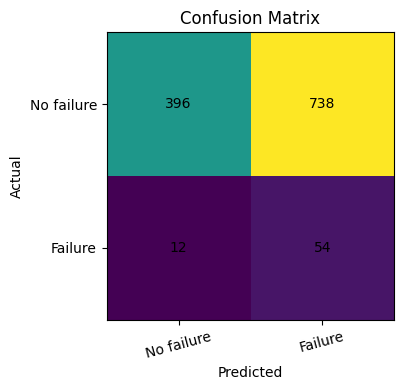

In [10]:
# Select the best model found by the grid search.
final_model = gs.best_estimator_

# Fit it on the full training set.
final_model.fit(X_train, y_train)

# Generate predictions for the unseen test set.
y_pred = final_model.predict(X_test)

# Calculate recall on the test set.
test_recall = recall_score(y_test, y_pred)
print("Test recall:", round(test_recall, 3))

# Show the full classification report.
# This includes precision, recall, f1-score, and support.
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

# Build and display the confusion matrix.
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)
pretty_confusion_matrix(cm)


### How to interpret the confusion matrix

The confusion matrix shows four outcomes:

- **true negatives**: correctly predicted no-failure cases
- **true positives**: correctly predicted failure cases
- **false positives**: trucks flagged as failures that did not fail
- **false negatives**: trucks that were going to fail but were missed

In this lab, false negatives are especially important because they represent failures that might not get preventive attention.


## 9) Final feature importance

Now inspect the feature importance values from the tuned model.

### Questions to consider

- Which features remain important after tuning?
- Did the tuned model rely on different signals than the baseline?
- Are the strongest signals operationally plausible in a mining context?


In [11]:
# Recover the transformed feature names from the tuned model.
ohe2 = final_model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names2 = ohe2.get_feature_names_out(cat_cols)
feature_names2 = np.array(num_cols + list(cat_feature_names2))

# Extract and sort tuned-model feature importance values.
importances2 = final_model.named_steps["model"].feature_importances_

fi2 = (
    pd.DataFrame({"feature": feature_names2, "importance": importances2})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(fi2.head(15))


,feature,importance
0,hours_since_service,0.353090
1,engine_temp_c,0.324231
2,vibration_mm_s,0.247548
3,engine_oil_pressure_kpa,0.075131
4,load_tonnes,0.000000
5,ambient_temp_c,0.000000
6,fuel_rate_lph,0.000000
7,speed_kmh,0.000000
8,fault_code_count,0.000000
9,over_temp_flag,0.000000


## 10) Discussion and operational interpretation

Write your answers in a new Markdown cell.

1. Why is recall a more suitable metric than plain accuracy in this mining problem?
2. What are the operational consequences of a false negative?
3. What are the operational consequences of a false positive?
4. If the model creates too many false positives, how might a maintenance team respond?
5. Which features look most relevant, and why might they be meaningful for truck reliability?


## 11) Stretch tasks (optional)

1. **Cost-aware thresholding**  
   Try a probabilistic model such as logistic regression and choose a threshold that keeps recall high while controlling alert volume.

2. **Tree pruning**  
   Explore `ccp_alpha` to control tree complexity and reduce overfitting.

3. **Feature engineering**  
   Create additional features such as rolling averages, changes over time, or interaction terms if timestamps are available.

4. **Operational playbook**  
   Draft a short maintenance response process for trucks flagged as high risk.

5. **Model comparison**  
   Compare the decision tree with another classifier such as random forest or gradient boosting and evaluate whether recall improves.
